In [1]:
''' Comparing some numerical schemes so solve PDE problems: schemes like 
    Lax-Friedrich (with some viscosity), Lax - wendroff, and Active flux
    are compared, and result are displayed '''

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# u(x,0) = 1 if 0.2 <= x <= 0.8   or 0 otherwise  ---------- Initial condition  

In [2]:
# Parameters
a = 1   # wave speed
delta_x = 0.1   # spatial
delta_t = 0.05   # Time
x_values = np.arange(0, 1.1, delta_x)
t_values = np.arange(0, 1.1, delta_t)

# Initial condition
u_initial = np.where((x_values >= 0.2) & (x_values <= 0.8), 1, 0)

In [3]:
# The Lax-Friedrichs scheme
u_solution = np.zeros((len(t_values), len(x_values)))
u_solution[0, :] = u_initial

for n in range(1, len(t_values)):
    for i in range(1, len(x_values) - 1):
        u_solution[n, i] = 0.5 * (u_solution[n-1, i-1] + u_solution[n-1, i+1]) - 0.5 * delta_t / delta_x * a * (u_solution[n-1, i+1] - u_solution[n-1, i-1])



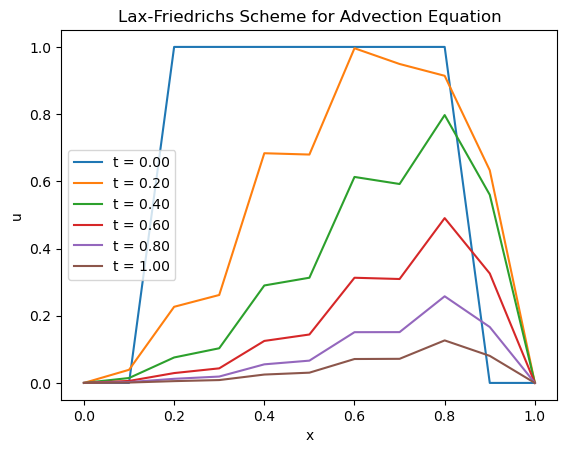

In [4]:
# Plotting for differnt time
for n in range(0, len(t_values), len(t_values)//5):
    plt.plot(x_values, u_solution[n, :], label=f't = {t_values[n]:.2f}')

plt.title('Lax-Friedrichs Scheme for Advection Equation')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Parameters
a = 1   # wave speed
delta_x = 0.1   # spatial
delta_t = 0.05   # Time
alpha = 0.01  # Artificial viscosity coefficient, which can be changed
x_values = np.arange(0, 1.1, delta_x)
t_values = np.arange(0, 1.1, delta_t)

# Initial condition
u_initial = np.where((x_values >= 0.2) & (x_values <= 0.8), 1, 0)

# Modified Lax-Friedrichs scheme with artificial viscosity, alpha
u_solution = np.zeros((len(t_values), len(x_values)))
u_solution[0, :] = u_initial

for n in range(1, len(t_values)):
    for i in range(1, len(x_values) - 1):
        u_solution[n, i] = 0.5 * (u_solution[n-1, i-1] + u_solution[n-1, i+1]) - 0.5 * delta_t / delta_x * a * (u_solution[n-1, i+1] - u_solution[n-1, i-1]) + 0.5 * alpha * (delta_x)**2 * (u_solution[n-1, i+1] - 2 * u_solution[n-1, i] + u_solution[n-1, i-1])




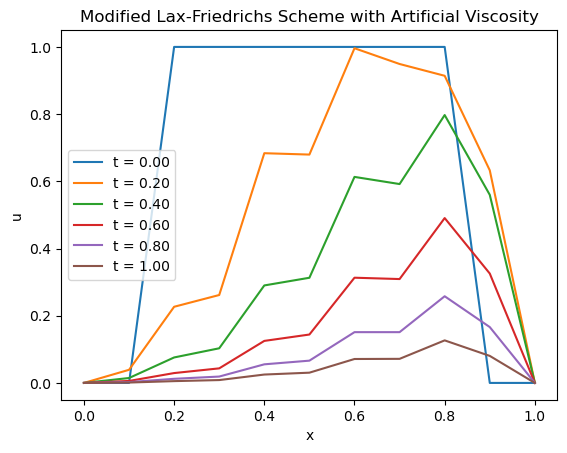

In [7]:
# Plotting our results
for n in range(0, len(t_values), len(t_values)//5):
    plt.plot(x_values, u_solution[n, :], label=f't = {t_values[n]:.2f}')

plt.title('Modified Lax-Friedrichs Scheme with Artificial Viscosity')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.show()


In [ ]:
# Active flux method
#

Error (Active Flux Method) for linear advection problem with sine wave initial condition: 0.7415166028582113


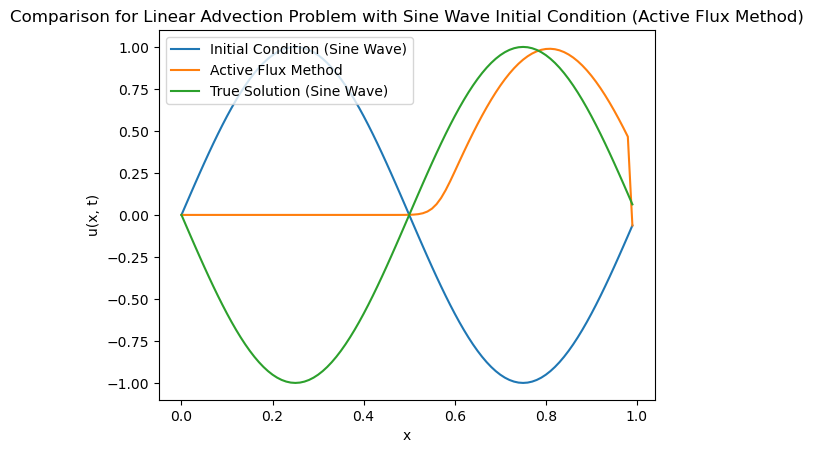

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def active_flux_method(u_initial, a, dt, dx, T):
    nt = int(T / dt)
    nx = len(u_initial)

    u = np.copy(u_initial)

    for n in range(nt):
        u_new = np.copy(u)
        for i in range(1, nx-1):
            alpha = a * dt / dx
            a_plus = max(0, a + alpha)
            a_minus = min(0, a - alpha)
            u_new[i] = u[i] - 0.5 * (a_plus * (u[i] - u[i-1]) + a_minus * (u[i+1] - u[i]))

        # Update the solution for the next time step
        u = np.copy(u_new)

    return u

# Parameters
a = 1.0  # Wave speed
L = 1.0  # Length of our domain
T = 0.5  # Total simulation of time
nx = 100  # Number of spatial grid points

# Spatial discretization
x = np.linspace(0, L, nx, endpoint=False)
dx = x[1] - x[0]

# We ensure CFL condition is satisfied
CFL = 0.8  # Adjust as needed
dt = CFL * dx / a

# Using smooth initial condition for the linear advection problem (sine wave)
u_initial_sine = np.sin(2 * np.pi * x)

# The true solution for the linear advection problem with the sine wave with IC
u_true_sine = np.sin(2 * np.pi * (x - a * T))

# Solving with Active Flux for the linear advection problem with the sine wave IC
u_active_flux_sine = active_flux_method(u_initial_sine, a, dt, dx, T)

# Computing errors for the linear advection problem with the sine wave IC
norm_u_true_sine = np.linalg.norm(u_true_sine, ord=2)
error_active_flux_sine = np.linalg.norm(u_active_flux_sine - u_true_sine, ord=2) / norm_u_true_sine

# Displaying errors for the linear advection problem with the sine wave IC
print(f"Error (Active Flux Method) for linear advection problem with sine wave initial condition: {error_active_flux_sine}")

# Plotting results for the linear advection problem with the sine wave IC
plt.plot(x, u_initial_sine, label='Initial Condition (Sine Wave)')
plt.plot(x, u_active_flux_sine, label='Active Flux Method')
plt.plot(x, u_true_sine, label='True Solution (Sine Wave)')
plt.legend()
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title('Comparison for Linear Advection Problem with Sine Wave Initial Condition (Active Flux Method)')
plt.show()


In [ ]:
# Combinning three schemes to check performances for same problem

Error (Lax-Friedrichs Method) for linear advection problem with sine wave initial condition: 0.710927245686115
Error (Lax-Wendroff Method) for linear advection problem with sine wave initial condition: 0.7073382669462465
Error (Active Flux Method) for linear advection problem with sine wave initial condition: 0.7415166028582113


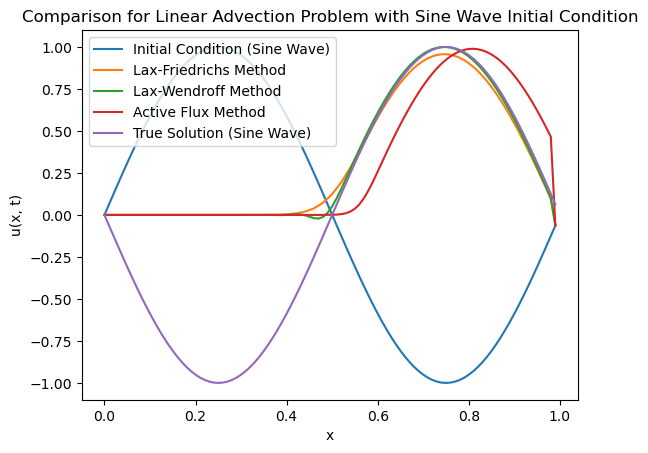

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# It is an order 1 scheme
def lax_friedrichs_method(u_initial, a, dt, dx, T):
    nt = int(T / dt)
    nx = len(u_initial)

    u = np.copy(u_initial)

    for n in range(nt):
        u_new = np.copy(u)
        for i in range(1, nx-1):
            alpha = a * dt / dx
            u_new[i] = 0.5 * (u[i+1] + u[i-1]) - 0.5 * alpha * (u[i+1] - u[i-1])

        # Updating the solution for the next time step
        u = np.copy(u_new)

    return u

# Lax wendroff is an order 2 scheme
def lax_wendroff_method(u_initial, a, dt, dx, T):
    nt = int(T / dt)
    nx = len(u_initial)

    u = np.copy(u_initial)

    for n in range(nt):
        u_new = np.copy(u)
        for i in range(1, nx-1):
            alpha = a * dt / dx
            alpha_sq = alpha**2
            u_new[i] = u[i] - 0.5 * alpha * (u[i+1] - u[i-1]) + 0.5 * alpha_sq * (u[i+1] - 2*u[i] + u[i-1])

        # Updating the solution for the next time step
        u = np.copy(u_new)

    return u

def active_flux_method(u_initial, a, dt, dx, T):
    nt = int(T / dt)
    nx = len(u_initial)

    u = np.copy(u_initial)

    for n in range(nt):
        u_new = np.copy(u)
        for i in range(1, nx-1):
            alpha = a * dt / dx
            a_plus = max(0, a + alpha)
            a_minus = min(0, a - alpha)
            u_new[i] = u[i] - 0.5 * (a_plus * (u[i] - u[i-1]) + a_minus * (u[i+1] - u[i]))

        # Updating the solution for the next time step
        u = np.copy(u_new)

    return u

# Parameters
a = 1.0  # Wave speed
L = 1.0  # Length of the domain
T = 0.5  # Total simulation of time
nx = 100  # Number of spatial grid points

# Spatial discretization
x = np.linspace(0, L, nx, endpoint=False)
dx = x[1] - x[0]

# Ensuring CFL condition is satisfied
CFL = 0.8  # You can adjust as you deem fit 
dt = CFL * dx / a

# Using smooth initial condition for the linear advection problem (sine wave)
u_initial_sine = np.sin(2 * np.pi * x)

# The true solution for the linear advection problem with the sine wave IC
u_true_sine = np.sin(2 * np.pi * (x - a * T))

# Solving with Lax-Friedrichs for the linear advection problem with the sine wave IC
u_lax_friedrichs_sine = lax_friedrichs_method(u_initial_sine, a, dt, dx, T)

# Solving with Lax-Wendroff for the linear advection problem with the sine wave IC
u_lax_wendroff_sine = lax_wendroff_method(u_initial_sine, a, dt, dx, T)

# Solving with Active Flux for the linear advection problem with the sine wave IC
u_active_flux_sine = active_flux_method(u_initial_sine, a, dt, dx, T)

# Computing errors for the linear advection problem with the sine wave IC
norm_u_true_sine = np.linalg.norm(u_true_sine, ord=2)
error_lax_friedrichs_sine = np.linalg.norm(u_lax_friedrichs_sine - u_true_sine, ord=2) / norm_u_true_sine
error_lax_wendroff_sine = np.linalg.norm(u_lax_wendroff_sine - u_true_sine, ord=2) / norm_u_true_sine
error_active_flux_sine = np.linalg.norm(u_active_flux_sine - u_true_sine, ord=2) / norm_u_true_sine

# Displaying errors for the linear advection problem with the sine wave IC
print(f"Error (Lax-Friedrichs Method) for linear advection problem with sine wave initial condition: {error_lax_friedrichs_sine}")
print(f"Error (Lax-Wendroff Method) for linear advection problem with sine wave initial condition: {error_lax_wendroff_sine}")
print(f"Error (Active Flux Method) for linear advection problem with sine wave initial condition: {error_active_flux_sine}")

# Plot results for the linear advection problem with the sine wave IC
plt.plot(x, u_initial_sine, label='Initial Condition (Sine Wave)')
plt.plot(x, u_lax_friedrichs_sine, label='Lax-Friedrichs Method')
plt.plot(x, u_lax_wendroff_sine, label='Lax-Wendroff Method')
plt.plot(x, u_active_flux_sine, label='Active Flux Method')
plt.plot(x, u_true_sine, label='True Solution (Sine Wave)')
plt.legend()
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title('Comparison for Linear Advection Problem with Sine Wave Initial Condition')
plt.show()
